<a href="https://colab.research.google.com/github/Racim-dev/MACHINE-LEARNING/blob/main/ENPC_TP6_Deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 6 Introduction to Deep Learning

------------------
Loic Landrieu 2024

------------------

We will explore a simple deep-learning pipeline on the CIFAR-10 dataset.

Let's first:
1. Import all libraries we'll need
2. Load and prepare the CIFAR-10 dataset (train, validation, test).
3. Visualize some example images.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
!pip install torchinfo
from torchinfo import summary

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import random

In [ ]:
# Transform: Convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))  # Standard CIFAR-10 normalization
])

# Download or load the CIFAR-10 dataset
train_val_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                 download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

# Let's split the train_val_dataset into an actual training set and a validation set
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

# Class names for reference
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

100%|██████████| 170M/170M [00:05<00:00, 28.5MB/s]


In [ ]:
# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Number of training samples:", len(train_dataset))
print("Number of validation samples:", len(val_dataset))
print("Number of test samples:", len(test_dataset))

Number of training samples: 45000
Number of validation samples: 5000
Number of test samples: 10000


In [ ]:
def visualize_random_images(dataset, classes, num_images=4, model=None, device=None):
    """
    Picks num_images random images from the dataset and displays them
    with their corresponding class labels. If a model is provided,
    it also displays the prediction in green if correct, or red otherwise.
    """
    plt.figure(figsize=(num_images*1.5, 1.5))

    for i in range(num_images):
        # Pick a random index
        idx = random.randint(0, len(dataset)-1)
        image, label = dataset[idx]

        # Unnormalize the image for display
        mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
        std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
        image_unnormalized = image * std + mean
        image_unnormalized = image_unnormalized.permute(1, 2, 0).numpy()  # C x H x W -> H x W x C

        plt.subplot(1, num_images, i+1)
        plt.imshow(np.clip(image_unnormalized, 0, 1))
        plt.axis('off')

        # If no model, just display the ground-truth label
        if model is None:
            plt.title(classes[label])
        else:
            # Evaluate model prediction
            model.eval()
            with torch.no_grad():
                input_img = image.unsqueeze(0)  # Shape: [1, 3, 32, 32]
                if device is not None:
                    input_img = input_img.to(device)

                output = model(input_img)
                pred = output.argmax(dim=1).item()

            # Pick the title color based on correctness
            title_color = "green" if pred == label else "red"
            plt.title(f"GT: {classes[label]}\nPred: {classes[pred]}", color=title_color)

    plt.tight_layout()
    plt.show()

Visualize 10 images from the dataset

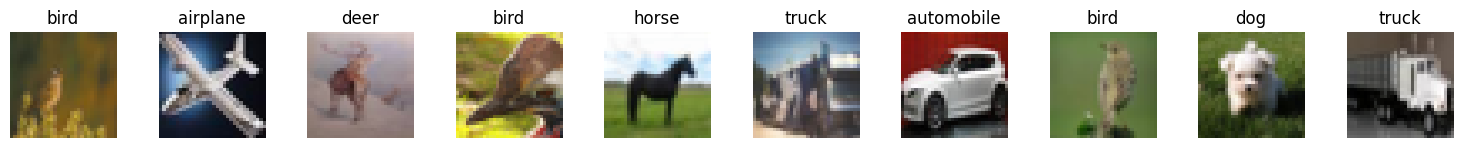

In [ ]:
# Show 4 random images from the training split
visualize_random_images(train_dataset, classes, num_images=10)


## MLP Baseline on Raw Pixels

We first establish a baseline with a simple Multilayer Perceptron (MLP).

**Key Idea**:
- Flatten each 32×32 color image (3×32×32 = 3072 values) into a vector.
- Pass this vector through one or more fully connected (linear) layers, with nonlinear activations.
- Compare performance on the validation set, and then on the test set once we find the best configuration.

This approach ignores the spatial structure of images (hence “baseline”), but it’s a useful first step.

Q1) Complete the MLP class.


In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dim=512, num_classes=10):
        super().__init__()
        # A simple MLP with 2 hidden layers:
        # input_dim -> hidden_dim -> hidden_dim -> num_classes
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


In [ ]:
summary(MLPClassifier(), input_size=(64, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
MLPClassifier                            [64, 10]                  --
├─Sequential: 1-1                        [64, 10]                  --
│    └─Linear: 2-1                       [64, 512]                 1,573,376
│    └─ReLU: 2-2                         [64, 512]                 --
│    └─Linear: 2-3                       [64, 512]                 262,656
│    └─ReLU: 2-4                         [64, 512]                 --
│    └─Linear: 2-5                       [64, 10]                  5,130
Total params: 1,841,162
Trainable params: 1,841,162
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 117.83
Input size (MB): 0.79
Forward/backward pass size (MB): 0.53
Params size (MB): 7.36
Estimated Total Size (MB): 8.68

We now write the main functions to train a neural network:
- **train_one_epoch**: runs through the dataset and updates the weights of the network to minimize the train loss
- **eval**: make predictions for the test ou val set, without updating weights

Q2) Complete the following functions.

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=1, num_epochs=1):
    """
    Runs one epoch of training, returns average loss and accuracy.
    Includes a tqdm progress bar with a 'Train' descriptor.
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # Create a progress bar over the training dataloader
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch}/{num_epochs} [Train]", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(dim=1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc


def evaluate(model, dataloader, criterion, device, desc="Val"):
    """
    Evaluates the model on a given dataloader (validation or test).
    Returns average loss and accuracy, with a tqdm progress bar.
    The 'desc' argument sets the bar label (e.g. 'Val' or 'Test').
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    # Create a progress bar over the evaluation dataloader
    progress_bar = tqdm(dataloader, desc=f"[{desc}]", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(dim=1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            # Optionally, update tqdm with current loss or accuracy
            current_loss = total_loss / total
            current_acc = 100.0 * correct / total
            progress_bar.set_postfix(loss=f"{current_loss:.1f}", acc=f"{current_acc:.2f}%")

    avg_loss = total_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc


We now write the main loop:
- run one peoch on the train set
- evaluate on the validation set
- if we reach the best value on the valdiation set, evaluate the test set

Q3) Complete the following function:

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5):

  print(1)

  print(summary(model, input_size=(64, 3, 32, 32)))

  best_val_acc = 0.0
  best_test_acc = 0.0  # Will store the highest test acc reached

  for epoch in range(1, num_epochs+1):
      # Train one epoch
      train_loss, train_acc = train_one_epoch(
          model=model,
          dataloader=train_loader,
          criterion=criterion,
          optimizer=optimizer,
          device=device,
          epoch=epoch,
          num_epochs=num_epochs
      )

      # Evaluate on validation set
      val_loss, val_acc = evaluate(
          model=model,
          dataloader=val_loader,
          criterion=criterion,
          device=device,
          desc="Val"
      )

      # Print color-coded lines for train and val
      print(f"\033[94m[Epoch {epoch} / {num_epochs}]\033[0m "
            f"Train Loss: {train_loss:.2f}, Train Acc: {train_acc:.1f}% | "
            f"Val Loss: {val_loss:.2f}, Val Acc: {val_acc:.1f}%")

      # Check if best on val -> Evaluate on test
      if val_acc > best_val_acc:
          best_val_acc = val_acc

          test_loss, test_acc = evaluate(
              model=model,
              dataloader=test_loader,
              criterion=criterion,
              device=device,
              desc="Test"
          )

          print(f"\033[92m  -> New best val acc! "
                f"Test Loss: {test_loss:.2f}, Test Acc: {test_acc:.1f}%\033[0m")
  return model, test_acc

You can now train your first neural network!

Q4) <font color='red'> Observe the evolution of train, val, and test losses (add moe epochs if needed) and comment. Why do we need a val set?</font>  
<font color='green'>
train acc increases consistently
test acc do not increase at each step
an increase in val acc usually corresponds to an increase in test acc
</font>

In [ ]:
# --- Instantiate model, criterion, optimizer ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = MLPClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

MLP_trained, best_test_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs)

Using device: cuda
1
Layer (type:depth-idx)                   Output Shape              Param #
MLPClassifier                            [64, 10]                  --
├─Sequential: 1-1                        [64, 10]                  --
│    └─Linear: 2-1                       [64, 512]                 1,573,376
│    └─ReLU: 2-2                         [64, 512]                 --
│    └─Linear: 2-3                       [64, 512]                 262,656
│    └─ReLU: 2-4                         [64, 512]                 --
│    └─Linear: 2-5                       [64, 10]                  5,130
Total params: 1,841,162
Trainable params: 1,841,162
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 117.83
Input size (MB): 0.79
Forward/backward pass size (MB): 0.53
Params size (MB): 7.36
Estimated Total Size (MB): 8.68


Epoch 1/10 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 1 / 10] Train Loss: 1.67, Train Acc: 40.9% | Val Loss: 1.58, Val Acc: 44.4%


[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

...

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 9 / 10] Train Loss: 0.94, Train Acc: 66.5% | Val Loss: 1.55, Val Acc: 51.0%


Epoch 10/10 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 10 / 10] Train Loss: 0.88, Train Acc: 68.5% | Val Loss: 1.63, Val Acc: 51.5%


Q5) Visualize 10 predictions of the model

---



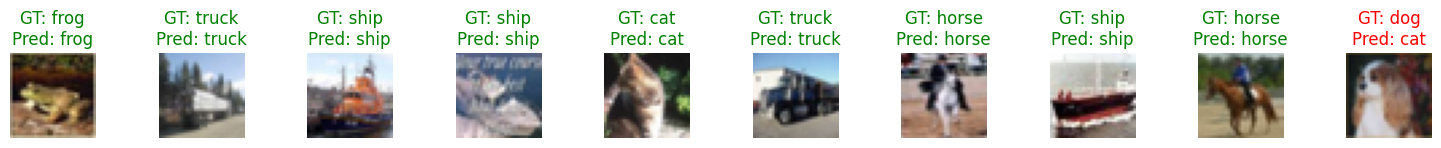

In [ ]:
visualize_random_images(train_dataset, classes, num_images=10, model=MLP_trained, device=device)

Q6) Complete the confusion matrix visualization code below, and
<font color='red'> comment on the results.</font>  
<font color='green'>
largest confusions are for similar classes: truck vs car, cat vs dog
</font>

In [ ]:
def view_confusion_matrix(model, device, test_loader):
  all_preds = []
  all_labels = []

  model.eval()
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = outputs.max(dim=1)

          all_preds.extend(predicted.cpu().numpy())
          all_labels.extend(labels.cpu().numpy())

  # 2. Compute confusion matrix
  cm = confusion_matrix(all_labels, all_preds)

  # 3. Visualize the confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=classes, yticklabels=classes)
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix - Test Set")
  plt.show()

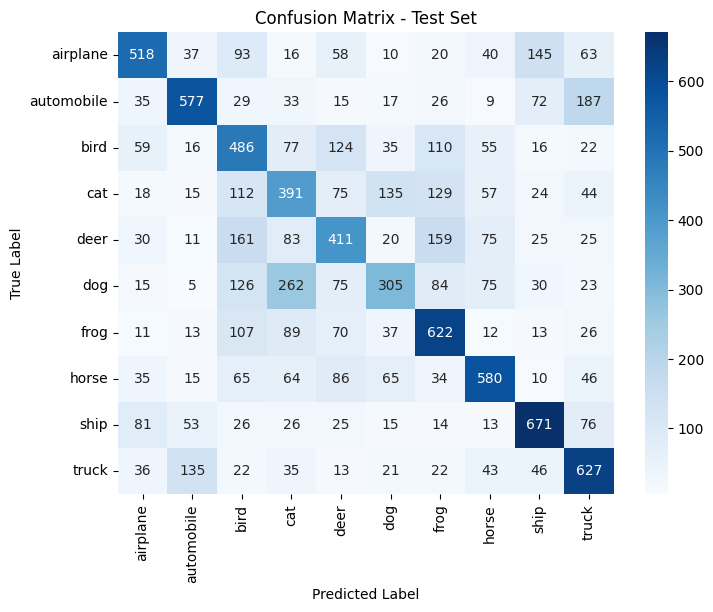

In [ ]:
view_confusion_matrix(MLP_trained, device, test_loader)

Q7) Add batchNorms (`nn.BatchNorm1d(DIM)`) to the model between the linears and the activation (never for the last layer!)


In [ ]:
class MLPClassifierBN(nn.Module):
    def __init__(self, input_dim=3*32*32, hidden_dim=512, num_classes=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten image
        return self.network(x)


model = MLPClassifierBN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10
MLP_trainedBN, best_test_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs)

1
Layer (type:depth-idx)                   Output Shape              Param #
MLPClassifierBN                          [64, 10]                  --
├─Sequential: 1-1                        [64, 10]                  --
│    └─Linear: 2-1                       [64, 512]                 1,573,376
│    └─BatchNorm1d: 2-2                  [64, 512]                 1,024
│    └─ReLU: 2-3                         [64, 512]                 --
│    └─Linear: 2-4                       [64, 512]                 262,656
│    └─BatchNorm1d: 2-5                  [64, 512]                 1,024
│    └─ReLU: 2-6                         [64, 512]                 --
│    └─Linear: 2-7                       [64, 10]                  5,130
Total params: 1,843,210
Trainable params: 1,843,210
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 117.97
Input size (MB): 0.79
Forward/backward pass size (MB): 1.05
Params size (MB): 7.37
Estimated Total Size (MB): 9.21


Epoch 1/10 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 1 / 10] Train Loss: 1.62, Train Acc: 42.1% | Val Loss: 1.49, Val Acc: 46.5%


[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

...

[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

  -> New best val acc! Test Loss: 1.33, Test Acc: 55.5%


Epoch 10/10 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 10 / 10] Train Loss: 0.77, Train Acc: 72.7% | Val Loss: 1.42, Val Acc: 55.1%


## Simple CNN on CIFAR-10

After establishing a baseline with an MLP on raw pixels, let's now use a simple Convolutional Neural Network (CNN). Convolutional layers help a model exploit the spatial (2D) structure of images, typically leading to better performance than a plain MLP for image classification tasks.

We'll implement a CNN with:
- Two convolutional layers, each followed by a nonlinearity (ReLU) and a pooling layer (MaxPool).
- A flatten operation to reshape the low resolution feature map into a vector
- A couple of fully connected (linear) layers at the end to perform classification on the extracted features.

Q8) Complete the following function and train the model. <font color='red'> comment on the results.</font>  
<font color='green'>
overall better! after 1 epoch already much better than MLP after 10. Good priors / inductive biases.
</font>


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Convolutional feature extractor
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (B, 3, 32, 32) -> (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> (B, 32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> (B, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2)                              # -> (B, 64, 8, 8)
        )

        # Fully connected classification head
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Pass input through conv layers
        x = self.conv_layers(x)               # (B, 64, 8, 8)
        x = x.view(x.size(0), -1)             # Flatten -> (B, 64*8*8)
        x = self.fc_layers(x)                 # -> (B, num_classes)
        return x


In [ ]:
# --- Instantiate model, criterion, optimizer ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5

CNN_trained, best_test_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs)

Using device: cuda
1
Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 8, 8]            --
│    └─Conv2d: 2-1                       [64, 32, 32, 32]          896
│    └─ReLU: 2-2                         [64, 32, 32, 32]          --
│    └─MaxPool2d: 2-3                    [64, 32, 16, 16]          --
│    └─Conv2d: 2-4                       [64, 64, 16, 16]          18,496
│    └─ReLU: 2-5                         [64, 64, 16, 16]          --
│    └─MaxPool2d: 2-6                    [64, 64, 8, 8]            --
├─Sequential: 1-2                        [64, 10]                  --
│    └─Linear: 2-7                       [64, 128]                 524,416
│    └─ReLU: 2-8                         [64, 128]                 --
│    └─Linear: 2-9                       [64, 10]                  1,290
Total params: 545,098
Trainable params: 545,098
Non

Epoch 1/5 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 1 / 5] Train Loss: 1.33, Train Acc: 52.5% | Val Loss: 1.05, Val Acc: 63.2%


[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 5/5 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 5 / 5] Train Loss: 0.58, Train Acc: 79.5% | Val Loss: 0.86, Val Acc: 71.1%


[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

  -> New best val acc! Test Loss: 0.84, Test Acc: 72.1%


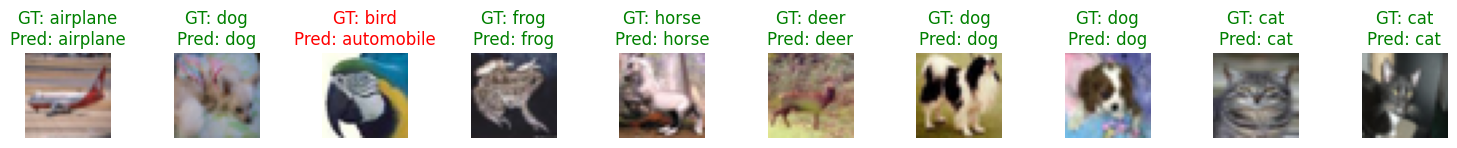

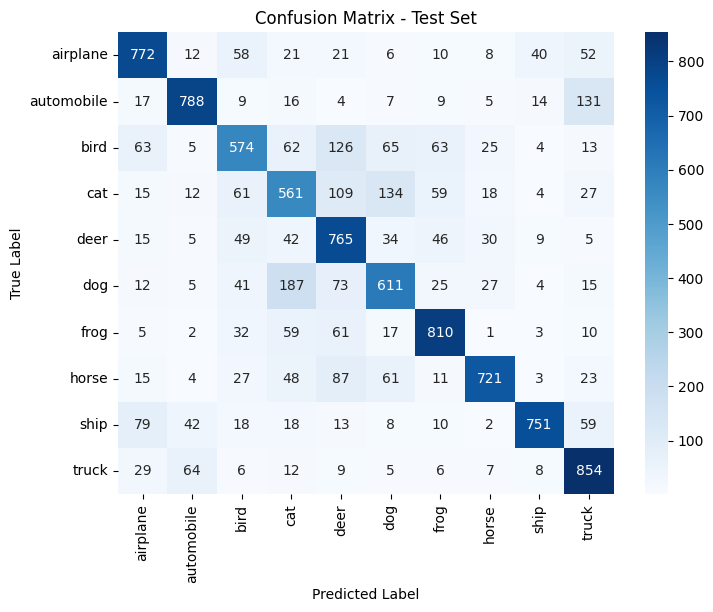

In [ ]:
visualize_random_images(train_dataset, classes, num_images=10, model=CNN_trained, device=device)
view_confusion_matrix(CNN_trained, device, test_loader)

Q9) We now want to visualize the activations of different learned filters. Compute the following code (no #TODOs here). <font color='red'> comment on the variety of activations.</font>  
<font color='green'>
different filters focus on different things: vertical/horizontal lines, bright/dark areas, etc
</font>

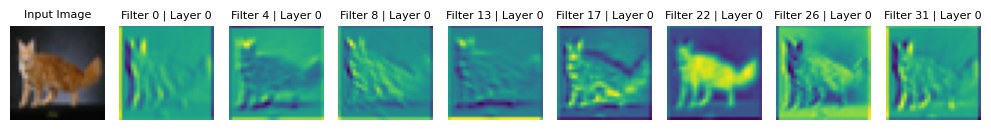

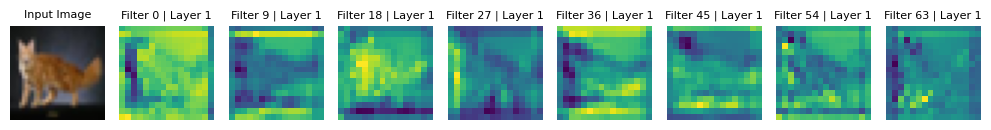

In [ ]:
def get_activation_direct(model_seq, input_image):
    """
    Given a sequential model (or a slice of the model) and an input image,
    returns the output (activation maps) by simply doing a forward pass.
    """
    # input_image is a tensor of shape [3, H, W]. Add a batch dimension.
    return model_seq(input_image.unsqueeze(0)).detach().cpu()

def plot_activations(input_image, activations, layer_idx, num_filters=8):
    """
    Plots the input image followed by `num_filters` activation maps.
    The activations tensor is expected to have shape [batch, channels, height, width].
    """
    activations = activations[0]  # use the first item in the batch
    num_total_filters = activations.shape[0]

    # Evenly select filter indices from all available filters
    filter_indices = torch.linspace(0, num_total_filters - 1, steps=num_filters).long()

    fig, axes = plt.subplots(1, num_filters + 1, figsize=(num_filters+2, 2))

    # Unnormalize and show the input image
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    input_unnorm = (input_image.cpu() * std + mean).permute(1, 2, 0).numpy()

    axes[0].imshow(input_unnorm)
    axes[0].set_title("Input Image", fontsize=8)
    axes[0].axis("off")

    # Plot selected activation maps
    for i, filter_idx in enumerate(filter_indices):
        act_map = activations[filter_idx]
        act_map = (act_map - act_map.min()) / (act_map.max() - act_map.min() + 1e-5)
        axes[i+1].imshow(act_map, cmap='viridis')
        axes[i+1].set_title(f"Filter {filter_idx.item()} | Layer {layer_idx}", fontsize=8)
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sample_img, _ = test_dataset[torch.randint(0, len(test_dataset), (1,)).item()]
sample_img = sample_img.to(device)

#Activations from the first conv layer:
layer_idx = 0
activations = get_activation_direct(model.conv_layers[0], sample_img)
plot_activations(sample_img, activations, layer_idx, num_filters=8)

# Activations from the second conv layer
layer_idx = 1
activations = get_activation_direct(model.conv_layers[:4], sample_img)
plot_activations(sample_img, activations, layer_idx, num_filters=8)


Q10) We did a very basic CNN. We can do much better. Implement your choice among the ideas below, and <font color='red'> comment on their individual impact.</font>. Then train your best model and report its test performance.
- Add a Dropout layer at the second to last layer <font color='green'> decrease train acc, increase test acc.</font>
- Add batchnormalization before each activation <font color='green'> faster convergence, decerase overfitting</font>
- Control the width of the network with a variable `base_channels` <font color='green'> larger is better - to a point</font>
- make the network deeper and visualize the activations <font color='green'> larger is better - to a point</font>
- train the network longer <font color='green'> longer is better , then saturate</font>
- replace the flatten by a spatial average or maximum (`torch.amax`) <font color='green'> decrease parameter count significantly. Mean is bad (influence of information outisde the object), but max is good, similar performance but faster and lighter!</font>
- anything else that you can think to improve the performance!

In [ ]:
class BetterCNN(nn.Module):
    """
    A simple CNN that includes:
    - Batch Normalization
    - Dropout
    - An extra convolutional layer
    - Width control via a 'base_channels' parameter
    """
    def __init__(self, base_channels=32, num_classes=10, dropout_rate=0):
        super().__init__()

        # Example of making the model "wider" or "narrower" using base_channels
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels),      # BatchNorm after conv
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(base_channels, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Extra convolutional layer
            nn.Conv2d(base_channels*2, base_channels*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Flatten and fully-connected part
        self.fc_layers = nn.Sequential(
            nn.Linear(base_channels*2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)   # Convolution + BN + ReLU + MaxPool + Dropout
        #x = x.max((2,3)) # Flatten
        x = torch.amax(x, (2,3))
        x = x.view(x.size(0), -1)
        nn.Dropout(0.5),
        x = self.fc_layers(x)     # Fully connected
        return x



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BetterCNN(base_channels=128, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Better_CNN_trained, best_test_acc = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20)

1
Layer (type:depth-idx)                   Output Shape              Param #
BetterCNN                                [64, 10]                  --
├─Sequential: 1-1                        [64, 256, 4, 4]           --
│    └─Conv2d: 2-1                       [64, 128, 32, 32]         3,584
│    └─BatchNorm2d: 2-2                  [64, 128, 32, 32]         256
│    └─ReLU: 2-3                         [64, 128, 32, 32]         --
│    └─MaxPool2d: 2-4                    [64, 128, 16, 16]         --
│    └─Conv2d: 2-5                       [64, 256, 16, 16]         295,168
│    └─BatchNorm2d: 2-6                  [64, 256, 16, 16]         512
│    └─ReLU: 2-7                         [64, 256, 16, 16]         --
│    └─MaxPool2d: 2-8                    [64, 256, 8, 8]           --
│    └─Conv2d: 2-9                       [64, 256, 8, 8]           590,080
│    └─BatchNorm2d: 2-10                 [64, 256, 8, 8]           512
│    └─ReLU: 2-11                        [64, 256, 8, 8]           

Epoch 1/20 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 1 / 20] Train Loss: 1.11, Train Acc: 60.7% | Val Loss: 0.89, Val Acc: 68.1%


[Test]:   0%|          | 0/157 [00:00<?, ?it/s]

...

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 19 / 20] Train Loss: 0.06, Train Acc: 97.8% | Val Loss: 1.04, Val Acc: 78.1%


Epoch 20/20 [Train]:   0%|          | 0/704 [00:00<?, ?it/s]

[Val]:   0%|          | 0/79 [00:00<?, ?it/s]

[Epoch 20 / 20] Train Loss: 0.04, Train Acc: 98.5% | Val Loss: 1.22, Val Acc: 75.9%


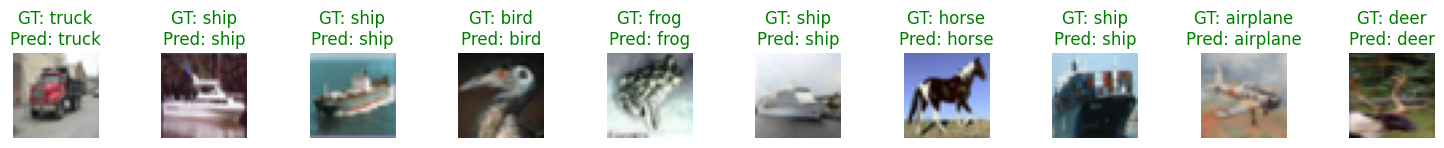

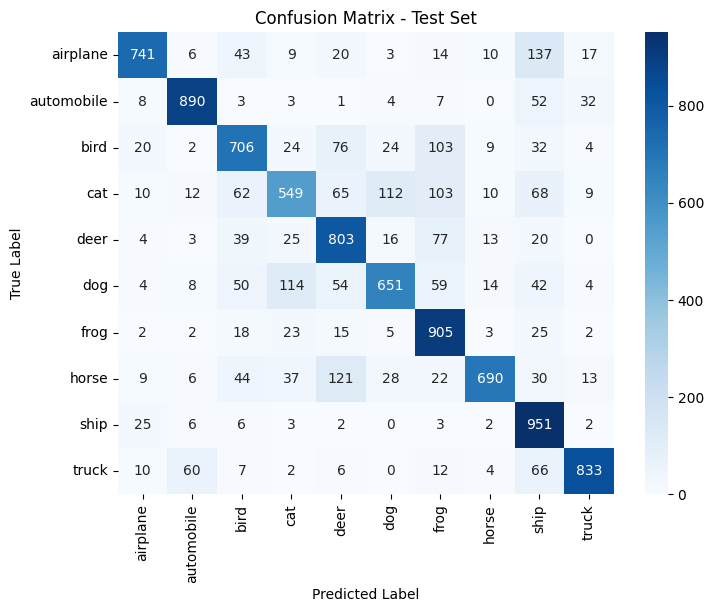

In [ ]:
visualize_random_images(train_dataset, classes, num_images=10, model=Better_CNN_trained, device=device)
view_confusion_matrix(Better_CNN_trained, device, test_loader)

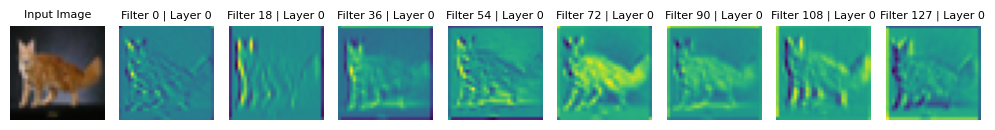

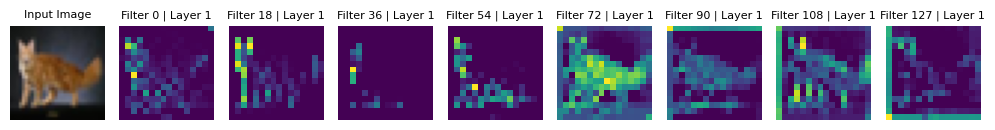

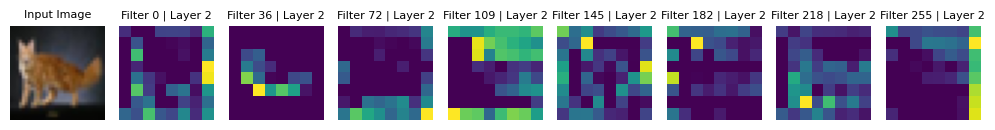

In [ ]:
model = Better_CNN_trained.to(device)
#Activations from the first conv layer:
layer_idx = 0
activations = get_activation_direct(model.conv_layers[0], sample_img)
plot_activations(sample_img, activations, layer_idx, num_filters=8)

# Activations from the second conv layer
layer_idx = 1
activations = get_activation_direct(model.conv_layers[:4], sample_img)
plot_activations(sample_img, activations, layer_idx, num_filters=8)

# Activations from the second conv layer
layer_idx = 2
activations = get_activation_direct(model.conv_layers[:8], sample_img)
plot_activations(sample_img, activations, layer_idx, num_filters=8)